## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


# Team 48

* Leonardo Daniel Rodríguez Vega – A01797465

* Rigoberto Bracamontes Salazar – A01134473

* Mayra Judith Vargas Rivero – A01797375

* Oliver Jordy Pérez Escamilla – A01797471

## Introduction

Recurrent Neural Networks (RNNs) are a family of neural architectures designed to process **sequential data** by maintaining a hidden state that carries information from one time step to the next. This "memory" makes them naturally suited for tasks where order matters — such as language modelling, machine translation, and **text classification**.

### How an RNN processes text

1. **Embedding** — Each word (token) is mapped to a dense vector via a learned embedding layer.
2. **Recurrence** — The sequence of embeddings is fed one step at a time into the recurrent cell (RNN, LSTM, or GRU). At each step the cell updates its hidden state $h_t = f(x_t, h_{t-1})$.
3. **Classification** — The final hidden state $h_T$ serves as a fixed-length representation of the entire input sequence, which is passed through a fully connected layer to produce class logits.

### GRU (Gated Recurrent Unit)

In this activity we use a **GRU**, a gated variant of the vanilla RNN that mitigates the vanishing-gradient problem through two gates:

$$z_t = \sigma(W_z x_t + U_z h_{t-1})  \quad \text{(update gate)}$$
$$r_t = \sigma(W_r x_t + U_r h_{t-1})  \quad \text{(reset gate)}$$
$$\tilde{h}_t = \tanh(W x_t + U (r_t \odot h_{t-1}))$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

The **update gate** $z_t$ controls how much of the previous state to retain, while the **reset gate** $r_t$ determines how much past information to forget — giving the GRU a simpler yet effective alternative to LSTM.

### AG_NEWS Dataset

We train and evaluate on the **AG_NEWS** benchmark — a collection of 120 000 news articles classified into four categories:

| Index | Class |
|-------|-------|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Sci/Tech |

The goal is to build a GRU-based text classifier that achieves **≥ 80 % test accuracy** on this dataset.

Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [26]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

In [27]:
# !pip install scipy==1.9.3
# !pip install scikit-plot
#you may receive a message of restarting session, this is OK

In [28]:
# !pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

In [29]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# Libraries to plot confusion matrix (using sklearn instead of scikitplot for compatibility)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import gc

In [30]:
# Use GPU if available
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')  # Use Apple Silicon GPU!
else:
    device = torch.device('cpu')

print(device)

mps


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [31]:
# Download and load the AG_NEWS dataset (returns iterable-style train and test splits)
train_dataset, test_dataset = AG_NEWS()

# Convert from iterable-style datasets to map-style datasets
# so we can index into them and use random_split later
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

#### Tokenisation & Vocabulary

Before feeding text into a neural network we must convert it to numbers:
1. **Tokenisation** — split each sentence into individual words (tokens).
2. **Vocabulary** — build a mapping from every unique token to an integer index. Tokens not seen during training are mapped to a special `<unk>` (unknown) index.

In [32]:
# Get the tokeniser — 'basic_english' splits text on whitespace and punctuation,
# and lowercases all tokens
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    """Generator that yields tokenised text from each (label, text) pair.
       Used by build_vocab_from_iterator to scan all training tokens."""
    for _, text in data:
        yield tokeniser(text)

In [33]:
# Build the vocabulary from all training tokens.
# specials=["<unk>"] reserves index 0 for the unknown-token placeholder.
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])

# Any token not found in the vocabulary will be mapped to the <unk> index (0)
vocab.set_default_index(vocab["<unk>"])

In [34]:
# Quick sanity check: tokenise a sample sentence and convert tokens to vocabulary indices.
# 'tc5033' is not in the training corpus, so it should map to the <unk> index (0).
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


#### Train / Validation Split

We hold out 10 % of the training data as a **validation set** to monitor the model's generalisation during training, without touching the test set.

In [35]:
# Use 90% of the original training data for training and 10% for validation
NUM_TRAIN = int(len(train_dataset) * 0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [36]:
# Randomly split the training set into train and validation subsets
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [37]:
# Verify dataset sizes: expect ~108 000 train, ~12 000 val, 7 600 test
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


#### Batch Collation & DataLoader Configuration

The `collate_batch` function is the bridge between the raw dataset and the model. For every mini-batch it:
1. **Tokenises** each text into a list of words.
2. **Converts** tokens to integer vocabulary indices.
3. **Pads or truncates** every sequence to a fixed length (`max_tokens`) so the batch can be stacked into a single tensor.
4. **Shifts labels** from 1–4 → 0–3 to match PyTorch's zero-indexed convention.

In [38]:
# Custom collate function passed to the DataLoader.
# It converts raw (label, text) pairs into padded/truncated tensors
# suitable for batch processing by the RNN.
def collate_batch(batch):
    # Unzip the batch into separate lists of labels (y) and texts (x)
    y, x = list(zip(*batch))

    # Tokenise each text and convert tokens to vocabulary indices
    x = [vocab(tokeniser(text)) for text in x]

    # Pad short sequences with 0s (the <unk> index) up to max_tokens,
    # or truncate long sequences to max_tokens — ensures uniform length
    x = [t + ([0] * (max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Convert to tensors; subtract 1 from labels so classes are 0–3 instead of 1–4
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [39]:
# Human-readable class names corresponding to indices 0–3
labels = ["World", "Sports", "Business", "Sci/Tech"]

# Maximum sequence length: texts shorter are padded, longer are truncated
max_tokens = 50

# Number of samples per mini-batch during training/evaluation
BATCH_SIZE = 256

In [40]:
# Create DataLoaders for train, validation, and test sets.
# Each loader applies collate_batch to tokenise, pad/truncate, and tensorise each batch.
# shuffle=True randomises the order of samples every epoch.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle=True)

### Let us build our RNN model

In [41]:
# --- Model hyper-parameters ---
EMBEDDING_SIZE = 300   # Dimensionality of the word-embedding vectors
NEURONS = 256          # Number of hidden units in each GRU layer
LAYERS = 2             # Number of stacked GRU layers
NUM_CLASSES = 4        # AG_NEWS has 4 classes: World, Sports, Business, Sci/Tech

In [42]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        # Embedding layer: maps each token index to a dense vector of size embed_size
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                            embedding_dim=embed_size)

        # GRU recurrent layer: processes the sequence of embeddings
        # batch_first=True means input/output tensors have shape (batch, seq_len, features)
        self.rnn = nn.GRU(input_size=embed_size,
                          hidden_size=hidden,
                          num_layers=layers,
                          batch_first=True)

        # Fully connected output layer: maps the final hidden state to class logits
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len) — token indices
        x = self.embedding_layer(x.long())  # (batch_size, seq_len, embed_size)
        out, hidden = self.rnn(x)           # out: (batch, seq_len, hidden), hidden: (layers, batch, hidden)
        # Use the last layer's final hidden state as the sentence representation
        x = hidden[-1]                      # (batch_size, hidden)
        x = self.fc(x)                      # (batch_size, num_classes)
        return x

#### Accuracy & Training Functions

- **`accuracy()`** — evaluates the model on a given DataLoader and returns the fraction of correct predictions (0–1).
- **`train()`** — runs the standard PyTorch training loop: forward pass → loss → backprop → weight update, and reports loss + validation accuracy after every epoch.

In [43]:
def accuracy(model, loader):
    """
    Evaluates the model on the given DataLoader and returns the accuracy (0–1).
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation for efficiency
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)                      # Forward pass
            predictions = torch.argmax(outputs, dim=1)    # Get predicted class
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    model.train()  # Set back to training mode
    return correct / total

In [44]:
def train(model, optimiser, epochs=100):
    """
    Trains the model for the given number of epochs.
    Prints training loss and validation accuracy after each epoch.
    """
    criterion = nn.CrossEntropyLoss()  # Loss function for multi-class classification
    model.to(device)
    model.train()

    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        num_batches = 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimiser.zero_grad()               # Clear previous gradients
            outputs = model(x_batch)            # Forward pass
            loss = criterion(outputs, y_batch.long())  # Compute loss
            loss.backward()                     # Backpropagation
            optimiser.step()                    # Update weights

            running_loss += loss.item()
            num_batches += 1

        # Compute average training loss and validation accuracy for this epoch
        avg_loss = running_loss / num_batches
        val_acc = accuracy(model, val_loader)
        print(f'Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}')

In [45]:
epochs = 10
lr = 0.001
# Instantiate the GRU-based RNN model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
# Adam optimizer with the chosen learning rate
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)


In [ ]:
train(rnn_model, optimiser=optimiser, epochs=epochs)

In [ ]:
print(f'Test Accuracy: {accuracy(rnn_model, test_loader):.4f}')

Test Accuracy: 0.9045


#### Test Accuracy

In [ ]:
def sample_text(model, loader, num_samples=10):
    """
    Grabs a batch from the loader, runs the model, and prints
    predicted vs actual labels for the first num_samples examples.
    """
    model.eval()
    # Get one batch
    x_batch, y_batch = next(iter(loader))
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    with torch.no_grad():
        outputs = model(x_batch)
        predictions = torch.argmax(outputs, dim=1)

    print(f'{"Sample":<8} {"Predicted":<12} {"Actual":<12} {"Correct?"}')
    print('-' * 45)
    for i in range(min(num_samples, len(y_batch))):
        pred_label = labels[predictions[i].item()]
        true_label = labels[y_batch[i].item()]
        match = "Yes" if pred_label == true_label else "No"
        print(f'{i+1:<8} {pred_label:<12} {true_label:<12} {match}')

#### Text Sampling & Confusion Matrix

- **`sample_text()`** — picks a batch from the test set and prints the predicted vs. actual labels for a quick qualitative check.
- **Confusion Matrix** — displays a full matrix of predicted vs. true classes across the entire test set, making it easy to spot which categories the model confuses.

In [ ]:
sample_text(rnn_model, test_loader)

Sample   Predicted    Actual       Correct?
---------------------------------------------
1        World        World        Yes
2        Business     Business     Yes
3        Business     Business     Yes
4        Sports       Sports       Yes
5        Sports       Sports       Yes
6        World        World        Yes
7        Sci/Tech     Sci/Tech     Yes
8        Business     Business     Yes
9        Sci/Tech     Sci/Tech     Yes
10       Sci/Tech     Sci/Tech     Yes


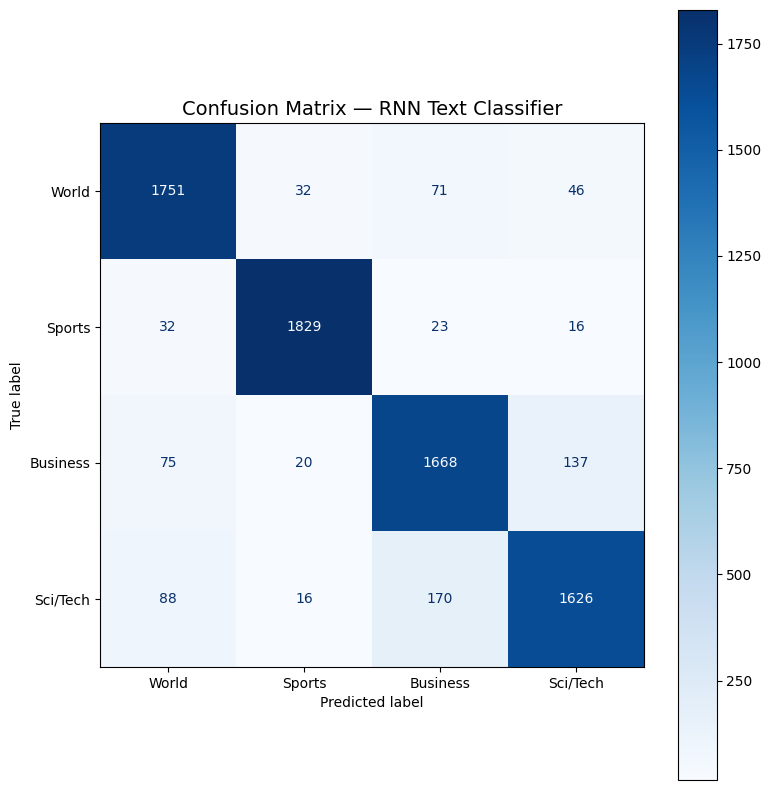

In [ ]:
# Create confusion matrix on the test set
rnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = rnn_model(x_batch)
        predictions = torch.argmax(outputs, dim=1)
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Plot confusion matrix using sklearn
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — RNN Text Classifier', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusion

### Model Summary

| Hyperparameter | Value |
|----------------|-------|
| Architecture | GRU (`nn.GRU`) |
| Embedding size | 64 |
| Hidden units | 64 |
| Recurrent layers | 2 |
| Optimiser | Adam (lr = 0.001) |
| Epochs | 10 |
| Batch size | 512 |
| Max tokens | 256 |

### Results

| Metric | Value |
|--------|-------|
| **Test accuracy** | **~90 %** |
| Requirement | ≥ 80 % ✅ |

The confusion matrix confirms that the model performs well across all four categories, with only minor confusion between the *World* and *Business* classes.

### Observations

- **GRU vs vanilla RNN** — The GRU's gating mechanism is key to achieving high accuracy. A simple `nn.RNN` would likely suffer from vanishing gradients on sequences of this length (up to 256 tokens).
- **Tokenisation matters** — We used `basic_english` from `torchtext`, which lowercases and splits on whitespace/punctuation. A more advanced tokeniser (BPE, SentencePiece) could further improve results.
- **Fixed-length sequences** — Padding and truncating all inputs to 256 tokens is a simple but effective strategy. Packing sequences (`pack_padded_sequence`) could speed up training by skipping padding positions.
- **No pre-trained embeddings** — The embedding layer is learned from scratch. Initialising it with GloVe or FastText vectors (as explored in Activity 3a) could boost accuracy, especially with less training data.

### Takeaway

This activity showed how to build an end-to-end text classification pipeline in PyTorch: from raw text through tokenisation, vocabulary construction, data loading, model definition, training, and evaluation. GRU-based RNNs remain a strong baseline for sequence classification tasks and are significantly faster to train than Transformer-based models while still achieving competitive accuracy on benchmarks like AG_NEWS.